In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\DELL\Downloads\pizza_sales.csv")

In [3]:
df.head()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,01-01-2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,01-01-2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,01-01-2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,01-01-2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,01-01-2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [5]:
df.set_index(df['pizza_id'],inplace=True)

In [7]:
df.head()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
pizza_id,,,,,,,,,,,,
1,1,1,hawaiian_m,1,01-01-2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
2,2,2,classic_dlx_m,1,01-01-2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
3,3,2,five_cheese_l,1,01-01-2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
4,4,2,ital_supr_l,1,01-01-2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
5,5,2,mexicana_m,1,01-01-2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [8]:
df.shape

(48620, 12)

In [9]:
df.columns

Index(['pizza_id', 'order_id', 'pizza_name_id', 'quantity', 'order_date',
       'order_time', 'unit_price', 'total_price', 'pizza_size',
       'pizza_category', 'pizza_ingredients', 'pizza_name'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48620 entries, 1 to 48620
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pizza_id           48620 non-null  int64  
 1   order_id           48620 non-null  int64  
 2   pizza_name_id      48620 non-null  object 
 3   quantity           48620 non-null  int64  
 4   order_date         48620 non-null  object 
 5   order_time         48620 non-null  object 
 6   unit_price         48620 non-null  float64
 7   total_price        48620 non-null  float64
 8   pizza_size         48620 non-null  object 
 9   pizza_category     48620 non-null  object 
 10  pizza_ingredients  48620 non-null  object 
 11  pizza_name         48620 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 4.8+ MB


Convert date from object to datetime


In [24]:
import datetime as dt
#df['order_date']=pd.to_datetime(df['order_date'])
df['order_date'] = pd.to_datetime(df['order_date'], format='%d-%m-%Y')
df['order_time'] = pd.to_datetime(df['order_time'])


C:\Users\DELL\AppData\Local\Temp\ipykernel_27128\3011538747.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['order_time'] = pd.to_datetime(df['order_time'])


In [25]:
df['year']=df['order_date'].dt.year
df['month']=df['order_date'].dt.month
df['month_name']=df['order_date'].dt.month_name()
df['day_name']=df['order_date'].dt.day_name()
df['hour']=df['order_time'].dt.hour

In [26]:
df.sample()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name,year,month,month_name,day_name,hour
pizza_id,,,,,,,,,,,,,,,,,
13670,13670,5992,mexicana_l,1,2015-04-11,2026-03-18 15:56:32,20.25,20.25,L,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza,2015,4,April,Saturday,15


In [28]:
for col in df.columns:
    print(col,":" , df[col].nunique())

pizza_id : 48620
order_id : 21350
pizza_name_id : 91
quantity : 4
order_date : 358
order_time : 16382
unit_price : 25
total_price : 56
pizza_size : 5
pizza_category : 4
pizza_ingredients : 32
pizza_name : 32
year : 1
month : 12
month_name : 12
day_name : 7
hour : 15


In [32]:
for col in df.columns:
    print(col,":" , df[col].value_counts())

pizza_id : pizza_id
48620    1
1        1
2        1
3        1
4        1
        ..
17       1
16       1
15       1
14       1
13       1
Name: count, Length: 48620, dtype: int64
order_id : order_id
18845    21
10760    21
20710    15
18280    15
13906    15
         ..
13126     1
7         1
21327     1
21324     1
21321     1
Name: count, Length: 21350, dtype: int64
pizza_name_id : pizza_name_id
big_meat_s        1811
thai_ckn_l        1365
five_cheese_l     1359
four_cheese_l     1273
classic_dlx_m     1159
                  ... 
mexicana_s         160
calabrese_s         99
ckn_alfredo_s       96
green_garden_l      94
the_greek_xxl       28
Name: count, Length: 91, dtype: int64
quantity : quantity
1    47693
2      903
3       21
4        3
Name: count, dtype: int64
order_date : order_date
2015-11-26    261
2015-11-27    259
2015-10-15    258
2015-07-04    233
2015-07-03    207
             ... 
2015-12-27     87
2015-11-22     82
2015-12-29     77
2015-03-22     76
2015-12-30

Total Revenue

In [33]:
df['total_price'].sum()

np.float64(817860.05)

Peak month

In [38]:
df.groupby('month_name')['total_price'].sum().sort_values(ascending=False)

month_name
July         72557.90
May          71402.75
March        70397.10
November     70395.35
January      69793.30
April        68736.80
August       68278.25
June         68230.20
February     65159.60
December     64701.15
September    64180.05
October      64027.60
Name: total_price, dtype: float64

<Axes: xlabel='month_name'>

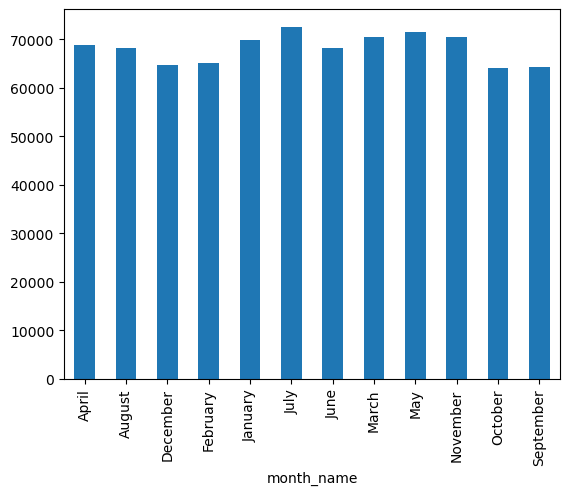

In [89]:
df.groupby('month_name')['total_price'].sum().plot(kind='bar')


Peak day

In [45]:
df.groupby('day_name')['total_price'].sum().sort_values(ascending=False)


day_name
Friday       136073.90
Thursday     123528.50
Saturday     123182.40
Wednesday    114408.40
Tuesday      114133.80
Monday       107329.55
Sunday        99203.50
Name: total_price, dtype: float64

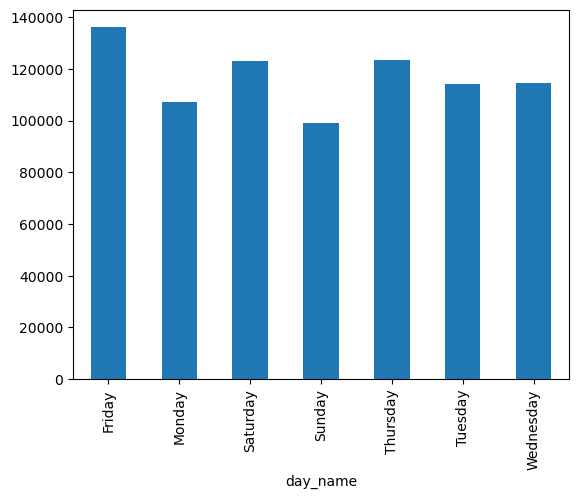

In [43]:
df.groupby('day_name')['total_price'].sum().plot(kind='bar')
plt.show()

Peak Hour

In [76]:
df.groupby('hour')['total_price'].sum().sort_values(ascending=False)


hour
12    111877.90
13    106065.70
18     89296.85
17     86237.45
19     72628.90
16     70055.40
14     59201.40
20     58215.40
15     52992.30
11     44935.80
21     42029.80
22     22815.15
23      1121.35
10       303.65
9         83.00
Name: total_price, dtype: float64

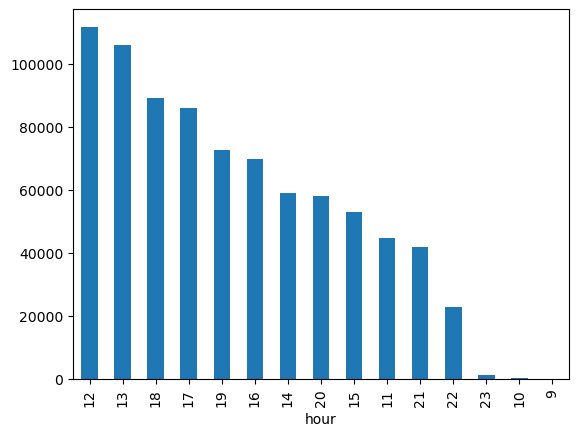

In [77]:
df.groupby('hour')['total_price'].sum().sort_values(ascending=False).plot(kind='bar')
plt.show()
                                                                        


The most soled pizza

In [49]:
df['pizza_name'].value_counts().sort_values(ascending=False).head(1)

pizza_name
The Classic Deluxe Pizza    2416
Name: count, dtype: int64

The most 5 soled pizza

In [53]:
df['pizza_name'].value_counts().sort_values(ascending=False).head(5)

pizza_name
The Classic Deluxe Pizza      2416
The Barbecue Chicken Pizza    2372
The Hawaiian Pizza            2370
The Pepperoni Pizza           2369
The Thai Chicken Pizza        2315
Name: count, dtype: int64

In [90]:
df['pizza_name'].value_counts().sort_values(ascending=False).tail(5)

pizza_name
The Spinach Pesto Pizza      957
The Spinach Supreme Pizza    940
The Calabrese Pizza          927
The Mediterranean Pizza      923
The Brie Carre Pizza         480
Name: count, dtype: int64

<Axes: xlabel='pizza_name'>

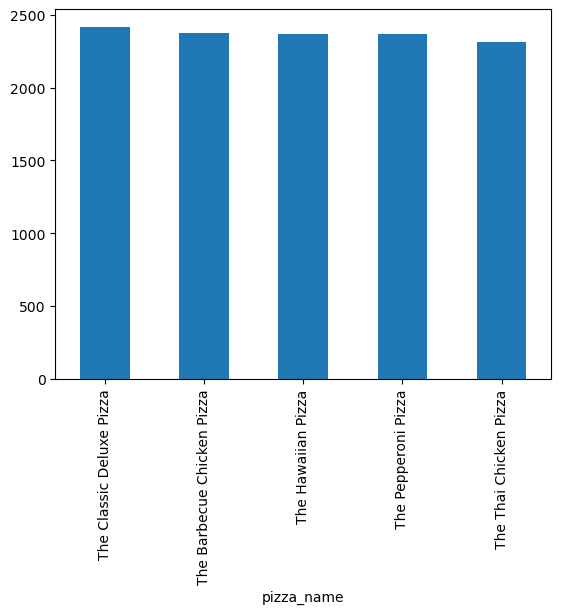

In [52]:
df['pizza_name'].value_counts().sort_values(ascending=False).head(5).plot(kind='bar')

The top 5 pizzas by total revenue

In [54]:
df.groupby('pizza_name')['total_price'].sum().sort_values(ascending=False).head(5)

pizza_name
The Thai Chicken Pizza          43434.25
The Barbecue Chicken Pizza      42768.00
The California Chicken Pizza    41409.50
The Classic Deluxe Pizza        38180.50
The Spicy Italian Pizza         34831.25
Name: total_price, dtype: float64

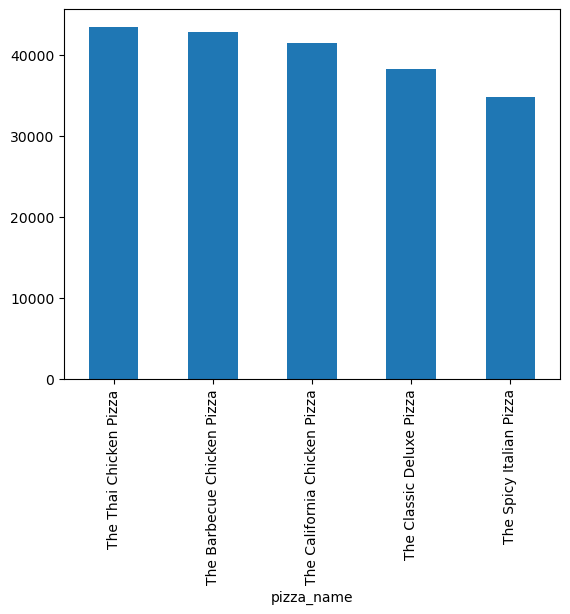

In [56]:
df.groupby('pizza_name')['total_price'].sum().sort_values(ascending=False).head(5).plot(kind='bar')
plt.show()

Most popular pizzas (by number of orders) 🍕

In [58]:
df.groupby('pizza_name')['quantity'].sum().sort_values(ascending=False)

pizza_name
The Classic Deluxe Pizza                      2453
The Barbecue Chicken Pizza                    2432
The Hawaiian Pizza                            2422
The Pepperoni Pizza                           2418
The Thai Chicken Pizza                        2371
The California Chicken Pizza                  2370
The Sicilian Pizza                            1938
The Spicy Italian Pizza                       1924
The Southwest Chicken Pizza                   1917
The Big Meat Pizza                            1914
The Four Cheese Pizza                         1902
The Italian Supreme Pizza                     1884
The Vegetables + Vegetables Pizza             1526
The Mexicana Pizza                            1484
The Napolitana Pizza                          1464
The Prosciutto and Arugula Pizza              1457
The Pepper Salami Pizza                       1446
The Spinach and Feta Pizza                    1446
The Italian Capocollo Pizza                   1438
The Greek Pizza     

In [60]:
df.columns

Index(['pizza_id', 'order_id', 'pizza_name_id', 'quantity', 'order_date',
       'order_time', 'unit_price', 'total_price', 'pizza_size',
       'pizza_category', 'pizza_ingredients', 'pizza_name', 'year', 'month',
       'month_name', 'day_name', 'hour'],
      dtype='object')

Most expensive pizzas (based on their max price) 💰

In [62]:
df.groupby('pizza_name')['unit_price'].max().sort_values(ascending=False)

pizza_name
The Greek Pizza                               35.95
The Brie Carre Pizza                          23.65
The Italian Vegetables Pizza                  21.00
The Barbecue Chicken Pizza                    20.75
The Chicken Pesto Pizza                       20.75
The Italian Supreme Pizza                     20.75
The Chicken Alfredo Pizza                     20.75
The California Chicken Pizza                  20.75
The Soppressata Pizza                         20.75
The Southwest Chicken Pizza                   20.75
The Spicy Italian Pizza                       20.75
The Spinach Pesto Pizza                       20.75
The Spinach Supreme Pizza                     20.75
The Thai Chicken Pizza                        20.75
The Prosciutto and Arugula Pizza              20.75
The Pepper Salami Pizza                       20.75
The Napolitana Pizza                          20.50
The Classic Deluxe Pizza                      20.50
The Italian Capocollo Pizza                   20.50
T

In [66]:
df[df['pizza_name']=='The Classic Deluxe Pizza']['unit_price'].value_counts()

unit_price
16.0    1159
12.0     786
20.5     471
Name: count, dtype: int64

In [ ]:
pizza_name
The Thai Chicken Pizza          43434.25
The Barbecue Chicken Pizza      42768.00
The California Chicken Pizza    41409.50
The Classic Deluxe Pizza        38180.50
The Spicy Italian Pizza         34831.25
Name: total_price, dtype: float64

In [73]:
df[df['pizza_name']=='The Thai Chicken Pizza']['unit_price'].value_counts()

unit_price
20.75    1365
12.75     476
16.75     474
Name: count, dtype: int64

In [75]:
df[df['pizza_name']=='The Spicy Italian Pizza']['unit_price'].value_counts()

unit_price
20.75    1088
16.50     400
12.50     399
Name: count, dtype: int64

In [68]:
df[(df['pizza_name']=='The Classic Deluxe Pizza')&(df['unit_price']==16.0)]

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name,year,month,month_name,day_name,hour
pizza_id,,,,,,,,,,,,,,,,,
2,2,2,classic_dlx_m,1,2015-01-01,2026-03-18 11:57:40,16.0,16.0,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza,2015,1,January,Thursday,11
72,72,27,classic_dlx_m,1,2015-01-01,2026-03-18 15:11:17,16.0,16.0,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza,2015,1,January,Thursday,15
91,91,36,classic_dlx_m,1,2015-01-01,2026-03-18 16:54:09,16.0,16.0,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza,2015,1,January,Thursday,16
134,134,56,classic_dlx_m,1,2015-01-01,2026-03-18 19:07:00,16.0,16.0,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza,2015,1,January,Thursday,19
137,137,57,classic_dlx_m,1,2015-01-01,2026-03-18 19:10:51,16.0,16.0,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza,2015,1,January,Thursday,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48413,48413,21257,classic_dlx_m,1,2015-12-30,2026-03-18 13:46:20,16.0,16.0,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza,2015,12,December,Wednesday,13
48440,48440,21271,classic_dlx_m,1,2015-12-30,2026-03-18 19:07:52,16.0,16.0,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza,2015,12,December,Wednesday,19
48467,48467,21288,classic_dlx_m,3,2015-12-31,2026-03-18 13:04:18,16.0,48.0,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza,2015,12,December,Thursday,13


In [70]:
df[(df['pizza_name']=='The Classic Deluxe Pizza')&(df['unit_price']==16.0)]['pizza_size'].value_counts()

pizza_size
M    1159
Name: count, dtype: int64

category is the most common in the dataset

In [79]:
df['pizza_category'].value_counts()

pizza_category
Classic    14579
Supreme    11777
Veggie     11449
Chicken    10815
Name: count, dtype: int64

Which category generates the most money 💰

In [91]:
df.groupby('pizza_category')['total_price'].sum().sort_values(ascending=False)

pizza_category
Classic    220053.10
Supreme    208197.00
Chicken    195919.50
Veggie     193690.45
Name: total_price, dtype: float64

<Axes: xlabel='pizza_category'>

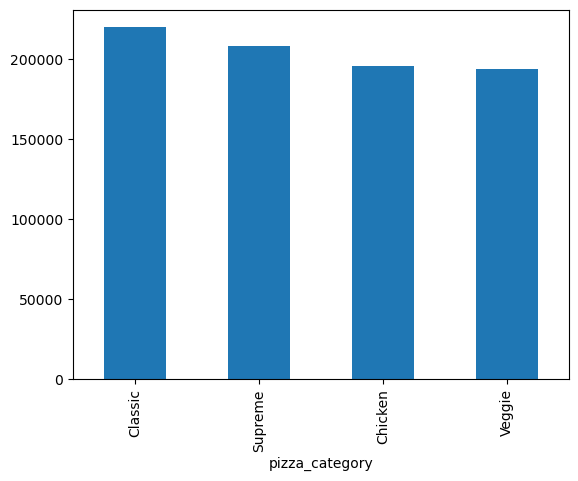

In [92]:
df.groupby('pizza_category')['total_price'].sum().sort_values(ascending=False).plot(kind='bar')

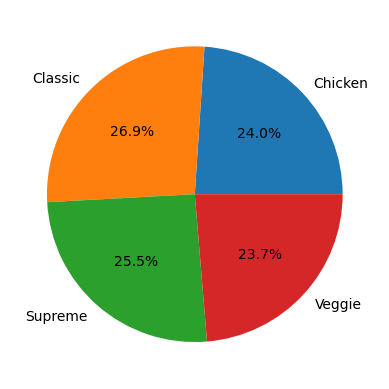

In [82]:
df.groupby('pizza_category')['total_price'].sum().plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.show()

The Top  soled pizza day 

In [85]:
df.groupby('order_date')['quantity'].sum().sort_values(ascending=False)

order_date
2015-11-26    266
2015-11-27    264
2015-10-15    262
2015-07-04    234
2015-07-03    213
             ... 
2015-12-27     89
2015-11-22     84
2015-12-30     82
2015-12-29     80
2015-03-22     77
Name: quantity, Length: 358, dtype: int64

In [88]:
df[df['order_date']=='2015-11-26']['day_name'].value_counts()

day_name
Thursday    261
Name: count, dtype: int64